# Aggregating kidney benchmarking results

In [1]:
import os

In [2]:
import numpy as np 
import scanpy as sc  
import pandas as pd

import squidpy as sq
import anndata as ad

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import entropy

/software/cellgen/team361/ms83/envs/mintflow-revision/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/software/cellgen/team361/ms83/envs/mintflow-revision/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/software/cellgen/team361/ms83/envs/mintflow-revision/lib/python3.11/site-packages/squidpy/gr/_utils.py:23: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('annd

In [3]:
# Define the base path
base_path = '/nfs/users/nfs_m/ms83/mintflow-revision/benchmarking'

# Define kidney clusters
kidney_clusters = {
    'TLS_border': 'kidney_TLSborder_metrics.csv',
    'TLS_score1': 'kidney_TLSscore1_metrics.csv',
    'TLS_score2': 'kidney_TLScore2_metrics.csv'
}

methods = ['utag', 'cellcharter', 'STAGATE', 'graphST', 'ncem']

In [4]:
all_results_kidney = []

for method in methods:
    for cluster_name, filename in kidney_clusters.items():
        path = f'{base_path}/{method}/analysis/{filename}'
        
        if os.path.exists(path):
            df = pd.read_csv(path)
            df['method'] = method
            df['cluster'] = cluster_name
            all_results_kidney.append(df)
            print(f"Loaded {method} - {cluster_name}: {len(df)} rows")
        else:
            print(f"WARNING: File not found - {method} - {cluster_name}: {path}")

# Combine all results
combined_results_kidney = pd.concat(all_results_kidney, ignore_index=True)

print(f"\nTotal combined results: {len(combined_results_kidney)} rows")
print(f"\nMethods: {combined_results_kidney['method'].unique()}")
print(f"Clusters: {combined_results_kidney['cluster'].unique()}")
print(f"\nData per method and cluster:")
print(combined_results_kidney.groupby(['method', 'cluster']).size())

Loaded utag - TLS_border: 64 rows
Loaded utag - TLS_score1: 64 rows
Loaded utag - TLS_score2: 64 rows
Loaded cellcharter - TLS_border: 64 rows
Loaded cellcharter - TLS_score1: 64 rows
Loaded cellcharter - TLS_score2: 64 rows
Loaded STAGATE - TLS_border: 64 rows
Loaded STAGATE - TLS_score1: 64 rows
Loaded STAGATE - TLS_score2: 64 rows
Loaded graphST - TLS_border: 64 rows
Loaded graphST - TLS_score1: 64 rows
Loaded graphST - TLS_score2: 64 rows
Loaded ncem - TLS_border: 64 rows
Loaded ncem - TLS_score1: 64 rows
Loaded ncem - TLS_score2: 64 rows

Total combined results: 960 rows

Methods: ['utag' 'cellcharter' 'STAGATE' 'graphST' 'ncem']
Clusters: ['TLS_border' 'TLS_score1' 'TLS_score2']

Data per method and cluster:
method       cluster   
STAGATE      TLS_border    64
             TLS_score1    64
             TLS_score2    64
cellcharter  TLS_border    64
             TLS_score1    64
             TLS_score2    64
graphST      TLS_border    64
             TLS_score1    64
            

In [5]:
combined_results_kidney

,Unnamed: 0,recall,precision,f1,split_entropy,best_cluster,n_clusters_with_niche,resolution,k_neighbors,method,cluster
0,0,0.313346,0.067613,0.111226,2.813489,2,16,0.3,3,utag,TLS_border
1,1,0.411992,0.080835,0.135152,2.190087,6,9,0.3,4,utag,TLS_border
2,2,0.638298,0.062941,0.114583,1.693268,1,10,0.3,5,utag,TLS_border
3,3,0.599613,0.075499,0.134112,1.876281,3,9,0.3,6,utag,TLS_border
4,4,0.485493,0.053133,0.095783,2.097898,2,9,0.3,7,utag,TLS_border
...,...,...,...,...,...,...,...,...,...,...,...
955,59,0.077708,0.079920,0.078798,6.369583,0,184,1.0,6,ncem,TLS_score2
956,60,0.089849,0.083109,0.086348,6.112528,0,134,1.0,7,ncem,TLS_score2
957,61,0.091306,0.081597,0.086179,6.018075,0,118,1.0,8,ncem,TLS_score2
958,62,0.091792,0.081712,0.086459,6.021189,0,113,1.0,9,ncem,TLS_score2


In [6]:
# Save combined results
combined_results_kidney.to_csv('all_methods_kidney_combined_results.csv', index=False)
print("\nSaved combined results to 'all_methods_kidney_combined_results.csv'")


Saved combined results to 'all_methods_kidney_combined_results_noscVIVA.csv'


In [7]:
# Calculate average metrics across the 3 clusters for each method and parameter combination
avg_results_kidney = combined_results_kidney.groupby(['method', 'resolution', 'k_neighbors']).agg({
    'recall': 'mean',
    'precision': 'mean',
    'f1': 'mean',
    'split_entropy': 'mean'
}).reset_index()

print(f"Averaged results: {len(avg_results_kidney)} rows")
print(f"Methods: {avg_results_kidney['method'].unique()}")

Averaged results: 320 rows
Methods: ['STAGATE' 'cellcharter' 'graphST' 'ncem' 'utag']


/tmp/ipykernel_674403/774895284.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df_entropy, x='Method', y='Value', ax=axes[1], palette='Set2')


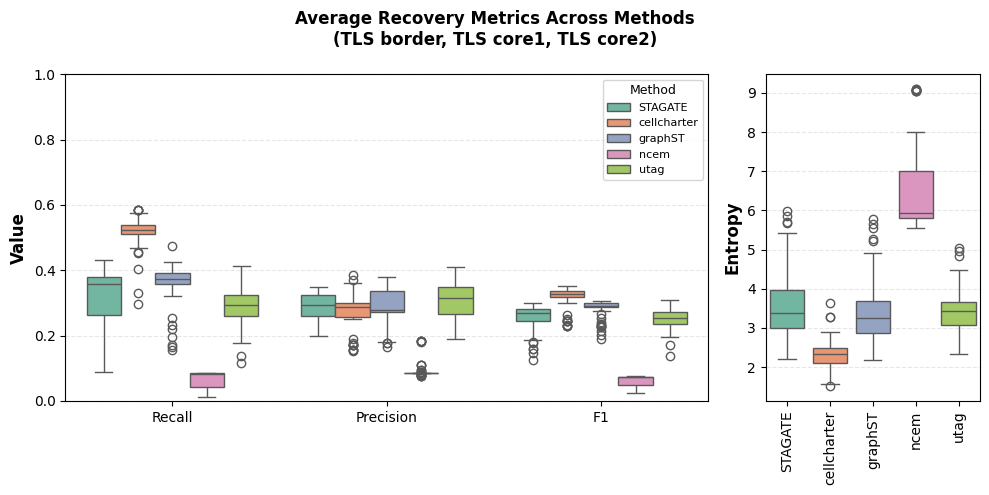

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), gridspec_kw={'width_ratios': [3, 1]})

# Left panel: Recall, Precision, F1
metrics_01 = ['recall', 'precision', 'f1']
plot_data_01 = []

for method in avg_results_kidney['method'].unique():
    method_data = avg_results_kidney[avg_results_kidney['method'] == method]
    for metric in metrics_01:
        for val in method_data[metric]:
            plot_data_01.append({
                'Method': method,
                'Metric': metric.replace('_', ' ').title(),
                'Value': val
            })

plot_df_01 = pd.DataFrame(plot_data_01)

# Create grouped boxplot
sns.boxplot(data=plot_df_01, x='Metric', y='Value', hue='Method', ax=axes[0], palette='Set2')

axes[0].set_ylabel('Value', fontsize=12, fontweight='bold')
axes[0].set_xlabel('', fontsize=12)
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].legend(title='Method', fontsize=8, title_fontsize=9)

# Right panel: Split Entropy
plot_data_entropy = []
for method in avg_results_kidney['method'].unique():
    method_data = avg_results_kidney[avg_results_kidney['method'] == method]
    for val in method_data['split_entropy']:
        plot_data_entropy.append({
            'Method': method,
            'Value': val
        })

plot_df_entropy = pd.DataFrame(plot_data_entropy)

sns.boxplot(data=plot_df_entropy, x='Method', y='Value', ax=axes[1], palette='Set2')

axes[1].set_ylabel('Entropy', fontsize=12, fontweight='bold')
axes[1].set_xlabel('', fontsize=12)
axes[1].tick_params(axis='x', rotation=90)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

plt.suptitle('Average Recovery Metrics Across Methods\n(TLS border, TLS core1, TLS core2)', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('methods_comparison_boxplots_kidney.pdf', dpi=300, bbox_inches='tight')
plt.show()